# Feature visualisation — frozen-backbone embeddings

Project per-spectrogram embeddings of one or two **frozen** backbones into 2-D and inspect how well classes separate.

Reads cached features from `results/features/{model}__{dataset}.npz` (produced by `scripts/run_eval.py`). No GPU / model download needed.

**Sections:**
1. Config — pick two models and a dataset
2. Load cached features
3. Projections — PCA, t-SNE, UMAP
4. Quantitative cluster quality — 1-NN purity, silhouette
5. Class-centroid cosine similarity
6. (Optional) Single-model deep dive

## 1. Imports & configuration

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES_DIR = REPO_ROOT / 'results' / 'features'
PLOTS_DIR    = REPO_ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

try:
    import umap
    HAVE_UMAP = True
    print(f'umap-learn {umap.__version__}  ✓')
except ImportError:
    HAVE_UMAP = False
    print('umap-learn not installed — UMAP cells will be skipped. Install with:\n'
          '    .venv/bin/pip install umap-learn')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

umap-learn 0.5.12  ✓


In [3]:
# What's available on disk?
available = sorted(FEATURES_DIR.glob('*.npz'))
by_dataset: dict[str, list[str]] = {}
for p in available:
    model, dataset = p.stem.split('__', 1)
    by_dataset.setdefault(dataset, []).append(model)

print(f'{len(available)} cached feature files in {FEATURES_DIR.relative_to(REPO_ROOT)}/\n')
for ds, models in sorted(by_dataset.items()):
    print(f'  {ds:25s}  →  {", ".join(sorted(models))}')

42 cached feature files in results/features/

  esc50                      →  dinov3_vitb16
  glasgow                    →  audiomae, beats_iter3, beats_iter3+, dasheng_06B, dasheng_base, dinov3_vitb16, fisher_small_4band, mae_imagenet, qwen2_audio, vjepa2.1_vitb, whisper_large_v3, whisper_small
  glasgow_5                  →  dasheng_base, dinov3_vitb16
  glasgow_mature             →  dasheng_base, dinov3_vitb16
  glasgow_young              →  dasheng_base
  mad                        →  audiomae, beats_iter3, dasheng_base, dinov3_vitb16, fisher_small_4band, mae_imagenet, vjepa2.1_vitb, whisper_small
  mad_5                      →  dasheng_base, dinov3_vitb16
  mad_5_sub1                 →  dasheng_base, dinov3_vitb16
  mad_5_sub2                 →  dasheng_base, dinov3_vitb16
  mad_5_sub23                →  dasheng_base, dinov3_vitb16
  mad_sub1                   →  dasheng_base, dinov3_vitb16
  mad_sub12                  →  dasheng_base
  mad_sub2                   →  dasheng_base
 

In [13]:
# ── Pick what to compare ───────────────────────────────────────────────────
MODEL_A  = 'dasheng_base'
MODEL_B  = 'dinov3_vitb16'      # set to None to do a single-model view
DATASET  = 'mad'

# ── Class-name overrides per dataset ───────────────────────────────────────
# Used purely for legend text; plots fall back to integer labels if absent.
CLASS_NAMES_BY_DATASET = {
    'glasgow':        ['Walking', 'Sitting down', 'Standing up',
                       'Picking up object', 'Drinking', 'Falling'],
    'glasgow_5':      ['Walking', 'Sitting down', 'Standing up',
                       'Picking up object', 'Falling'],
    'glasgow_young':  ['Walking', 'Sitting down', 'Standing up',
                       'Picking up object', 'Drinking', 'Falling'],
    'glasgow_mature': ['Walking', 'Sitting down', 'Standing up',
                       'Picking up object', 'Drinking', 'Falling'],
    'mad':            ['Walk', 'Stand', 'Sit', 'Up Stairs', 'Down Stairs',
                       'Pick', 'Step Over', 'Semi-Turn Around', 'Fall',
                       'Walk (Arbitrary)'],
    'mad_5':          ['Walk', 'Stand', 'Sit', 'Pick', 'Fall'],
}

# ── Projection knobs ───────────────────────────────────────────────────────
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST    = 0.1
RANDOM_STATE     = 42

# ── Subsampling for plots (None = use all) ────────────────────────────────
MAX_POINTS = None

print(f'Comparing  {MODEL_A!r}' + (f'  vs  {MODEL_B!r}' if MODEL_B else '  (single model)'))
print(f'Dataset    {DATASET!r}')

Comparing  'dasheng_base'  vs  'dinov3_vitb16'
Dataset    'mad'


## 2. Load cached features

In [14]:
def load_features(model: str, dataset: str) -> tuple[np.ndarray, np.ndarray]:
    path = FEATURES_DIR / f'{model}__{dataset}.npz'
    if not path.exists():
        raise FileNotFoundError(
            f'No cached features for {model!r} on {dataset!r}.\n'
            f'Run:  python scripts/run_eval.py --model {model} --dataset {dataset}'
        )
    data = np.load(path)
    return data['features'].astype(np.float32), data['labels'].astype(np.int64)

X_a, y = load_features(MODEL_A, DATASET)
print(f'{MODEL_A:>20s}  features={X_a.shape}  labels={y.shape}')

if MODEL_B is not None:
    X_b, y_b = load_features(MODEL_B, DATASET)
    print(f'{MODEL_B:>20s}  features={X_b.shape}  labels={y_b.shape}')
    assert np.array_equal(y, y_b), 'Label arrays differ between cached files — datasets must match.'
else:
    X_b = None

n_classes = int(y.max()) + 1
class_names = CLASS_NAMES_BY_DATASET.get(
    DATASET, [f'class {i}' for i in range(n_classes)]
)
if len(class_names) != n_classes:
    class_names = [f'class {i}' for i in range(n_classes)]

print(f'\nClasses ({n_classes}):')
for i, name in enumerate(class_names):
    print(f'  {i}  {name:25s}  n={int((y == i).sum())}')

# Optional subsample (stratified) — keep plots readable for large datasets.
if MAX_POINTS is not None and len(y) > MAX_POINTS:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_keep = []
    per_class = MAX_POINTS // n_classes
    for c in range(n_classes):
        idx_c = np.where(y == c)[0]
        idx_keep.append(rng.choice(idx_c, size=min(per_class, len(idx_c)), replace=False))
    idx = np.sort(np.concatenate(idx_keep))
    X_a, y = X_a[idx], y[idx]
    if X_b is not None:
        X_b = X_b[idx]
    print(f'\nSubsampled to {len(y)} points')

        dasheng_base  features=(12690, 768)  labels=(12690,)
       dinov3_vitb16  features=(12690, 768)  labels=(12690,)

Classes (10):
  0  Walk                       n=2152
  1  Stand                      n=1298
  2  Sit                        n=1298
  3  Up Stairs                  n=1294
  4  Down Stairs                n=1294
  5  Pick                       n=1292
  6  Step Over                  n=1290
  7  Semi-Turn Around           n=1276
  8  Fall                       n=1286
  9  Walk (Arbitrary)           n=210


## 3. Projections — PCA, t-SNE, UMAP

Each backbone gets its own row. Features are z-scored before projection so dimensions with very different scales don't dominate the layout.

- **PCA** — linear, deterministic, preserves global structure.
- **t-SNE** — non-linear, preserves local neighbourhoods; global distances are not meaningful.
- **UMAP** — non-linear, balances local + global; fastest of the three on large N.

In [15]:
def standardise(X: np.ndarray) -> np.ndarray:
    return StandardScaler().fit_transform(X)

def project_pca(X: np.ndarray) -> np.ndarray:
    return PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

def project_tsne(X: np.ndarray) -> np.ndarray:
    return TSNE(
        n_components=2,
        perplexity=min(TSNE_PERPLEXITY, max(5, len(X) // 4)),
        init='pca',
        learning_rate='auto',
        random_state=RANDOM_STATE,
    ).fit_transform(X)

def project_umap(X: np.ndarray) -> np.ndarray:
    if not HAVE_UMAP:
        return None
    return umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        n_components=2,
        random_state=RANDOM_STATE,
    ).fit_transform(X)

def scatter(ax, Z, labels, title, names, palette):
    if Z is None:
        ax.text(0.5, 0.5, 'umap-learn not installed', ha='center', va='center',
                transform=ax.transAxes, color='grey')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title)
        return
    for c in range(len(names)):
        m = labels == c
        ax.scatter(Z[m, 0], Z[m, 1], s=10, alpha=0.7, color=palette[c],
                   label=names[c], edgecolors='none')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

palette = sns.color_palette('tab10', n_colors=max(10, n_classes))[:n_classes]

In [16]:
models = [(MODEL_A, X_a)] + ([(MODEL_B, X_b)] if X_b is not None else [])

projections = {}
for name, X in models:
    print(f'Projecting {name} ({X.shape[1]}-D)…')
    Xs = standardise(X)
    projections[name] = {
        'pca':  project_pca(Xs),
        'tsne': project_tsne(Xs),
        'umap': project_umap(Xs),
    }
print('done.')

Projecting dasheng_base (768-D)…
Projecting dinov3_vitb16 (768-D)…
done.


Saved → results/plots/projections__dasheng_base_vs_dinov3_vitb16__mad.png


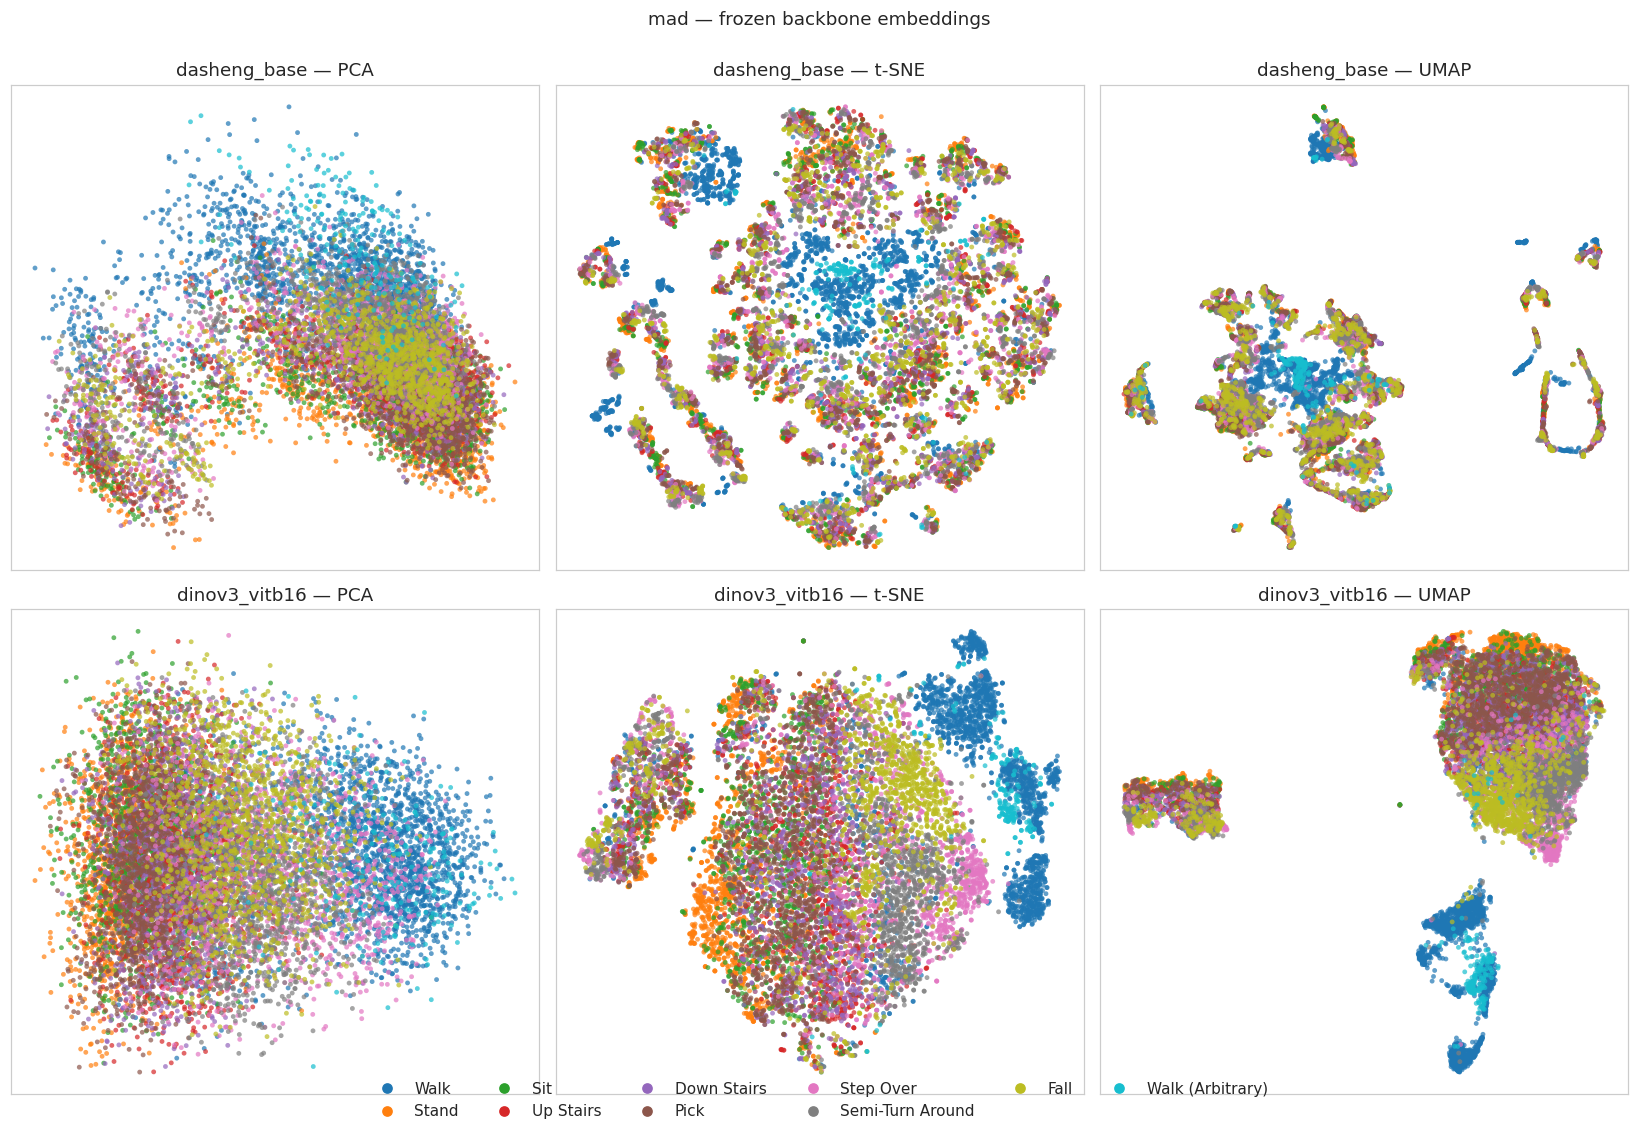

In [17]:
n_rows = len(models)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), squeeze=False)

for row, (name, _) in enumerate(models):
    Z = projections[name]
    scatter(axes[row, 0], Z['pca'],  y, f'{name} — PCA',   class_names, palette)
    scatter(axes[row, 1], Z['tsne'], y, f'{name} — t-SNE', class_names, palette)
    scatter(axes[row, 2], Z['umap'], y, f'{name} — UMAP',  class_names, palette)

# One legend for the whole figure.
handles = [plt.Line2D([], [], marker='o', linestyle='', color=palette[i],
                       markersize=6, label=class_names[i])
           for i in range(n_classes)]
fig.legend(handles=handles, loc='lower center', ncol=min(n_classes, 6),
           bbox_to_anchor=(0.5, -0.02), frameon=False)

plt.suptitle(f'{DATASET} — frozen backbone embeddings', y=1.0)
plt.tight_layout()
out = PLOTS_DIR / f'projections__{"_vs_".join([m for m, _ in models])}__{DATASET}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out.relative_to(REPO_ROOT)}')
plt.show()

## 4. Quantitative cluster quality

Three numbers per backbone, computed on the **full embedding** (not the 2-D projection):

- **1-NN accuracy (5-fold CV)** — for each point, ask its nearest neighbour (cosine) what label it has. High → tight per-class manifolds.
- **Silhouette (cosine)** — how much closer a point is to its own class centroid than to the next-nearest class. Range −1…1, higher is better.
- **Top-2 / Top-3 recall (5-fold CV)** — fraction of test points whose true class appears among the 2 (resp. 3) nearest training neighbours.

In [18]:
def knn_cv_metrics(X: np.ndarray, y: np.ndarray, ks=(1, 2, 3)) -> dict:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    out = {f'top{k}': [] for k in ks}
    for tr, te in skf.split(X, y):
        Xtr_s = StandardScaler().fit(X[tr])
        Xtr = Xtr_s.transform(X[tr])
        Xte = Xtr_s.transform(X[te])
        knn = KNeighborsClassifier(n_neighbors=max(ks), metric='cosine')
        knn.fit(Xtr, y[tr])
        # Indices of the K nearest train points for every test point.
        nbr = knn.kneighbors(Xte, return_distance=False)
        nbr_labels = y[tr][nbr]
        for k in ks:
            hit = (nbr_labels[:, :k] == y[te][:, None]).any(axis=1)
            out[f'top{k}'].append(hit.mean())
    return {k: (np.mean(v), np.std(v)) for k, v in out.items()}

rows = []
for name, X in models:
    Xs = StandardScaler().fit_transform(X)
    sil = silhouette_score(Xs, y, metric='cosine', sample_size=min(2000, len(y)),
                            random_state=RANDOM_STATE)
    knn = knn_cv_metrics(X, y, ks=(1, 2, 3))
    rows.append({
        'model':       name,
        'embed_dim':   X.shape[1],
        'silhouette':  sil,
        '1-NN acc':    knn['top1'][0],
        '1-NN ±':      knn['top1'][1],
        'top-2 recall': knn['top2'][0],
        'top-3 recall': knn['top3'][0],
    })

header = (f'{"model":<22s} {"D":>5s} {"silhouette":>11s} '
          f'{"1-NN acc":>10s} {"top-2":>8s} {"top-3":>8s}')
print(header)
print('-' * len(header))
for r in rows:
    print(f'{r["model"]:<22s} {r["embed_dim"]:>5d} '
          f'{r["silhouette"]:>11.3f} '
          f'{r["1-NN acc"]*100:>9.1f}% '
          f'{r["top-2 recall"]*100:>7.1f}% '
          f'{r["top-3 recall"]*100:>7.1f}%')

model                      D  silhouette   1-NN acc    top-2    top-3
---------------------------------------------------------------------
dasheng_base             768      -0.043      60.0%    73.2%    80.3%
dinov3_vitb16            768      -0.020      58.2%    72.1%    79.9%


## 5. Class-centroid cosine similarity

Mean-pool embeddings per class, then compute the cosine similarity between every pair of centroids. **Off-diagonal blocks** that are too bright (e.g. `Sit ↔ Stand`) signal classes the backbone struggles to separate.

Saved → results/plots/centroid_sim__dasheng_base_vs_dinov3_vitb16__glasgow.png


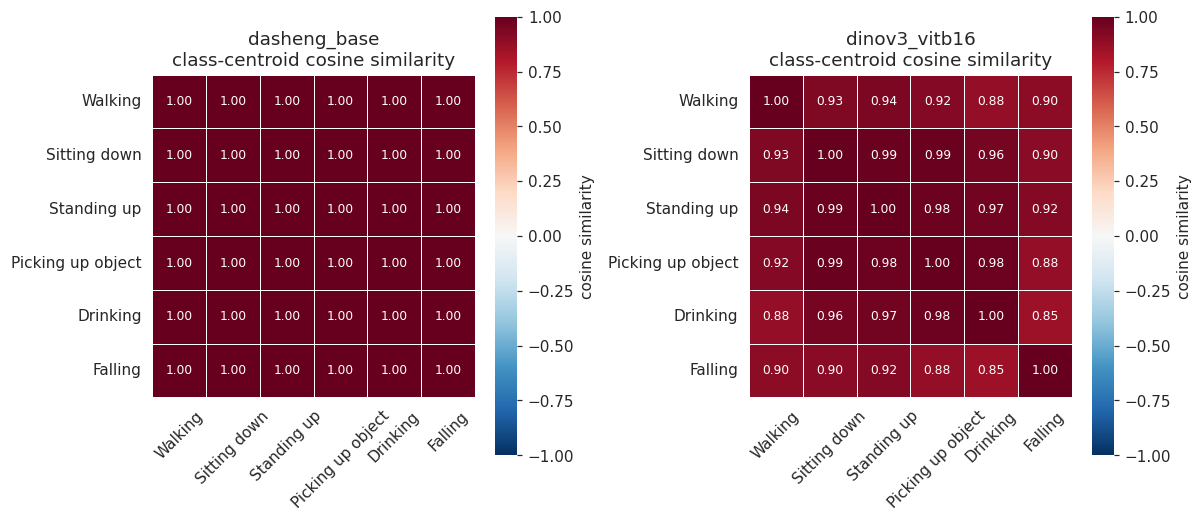

In [10]:
def class_centroid_similarity(X: np.ndarray, y: np.ndarray, n_classes: int) -> np.ndarray:
    centroids = np.stack([X[y == c].mean(axis=0) for c in range(n_classes)])
    return cosine_similarity(centroids)

fig, axes = plt.subplots(1, len(models), figsize=(5.5 * len(models), 5),
                          squeeze=False)
for ax, (name, X) in zip(axes[0], models):
    sim = class_centroid_similarity(X, y, n_classes)
    sns.heatmap(
        sim, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 8},
        xticklabels=class_names, yticklabels=class_names,
        cbar_kws={'label': 'cosine similarity'},
        square=True, linewidths=0.5, linecolor='white',
    )
    ax.set_title(f'{name}\nclass-centroid cosine similarity')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
out = PLOTS_DIR / f'centroid_sim__{"_vs_".join([m for m, _ in models])}__{DATASET}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved → {out.relative_to(REPO_ROOT)}')
plt.show()

## 6. (Optional) Single-model deep dive

Re-run section 3 with denser t-SNE / UMAP settings on a single backbone, useful when the side-by-side view above is too small to read. Set `FOCUS_MODEL` to whichever model you want to inspect.

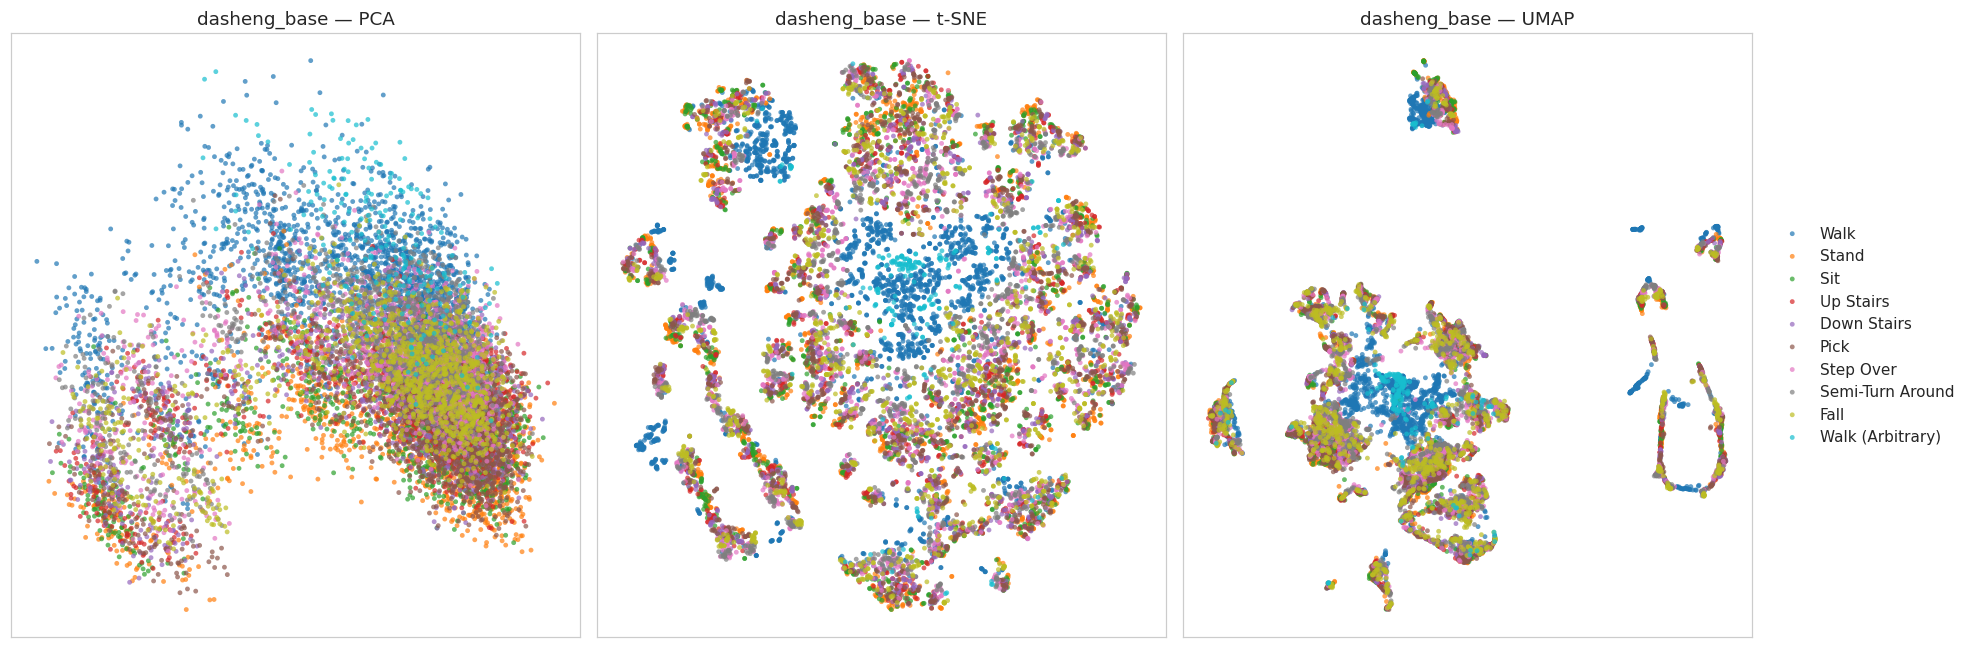

In [19]:
FOCUS_MODEL = MODEL_A   # or MODEL_B, or any other model name in by_dataset[DATASET]

X_focus, y_focus = load_features(FOCUS_MODEL, DATASET)
Xs = standardise(X_focus)

Z_pca  = project_pca(Xs)
Z_tsne = project_tsne(Xs)
Z_umap = project_umap(Xs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
scatter(axes[0], Z_pca,  y_focus, f'{FOCUS_MODEL} — PCA',   class_names, palette)
scatter(axes[1], Z_tsne, y_focus, f'{FOCUS_MODEL} — t-SNE', class_names, palette)
scatter(axes[2], Z_umap, y_focus, f'{FOCUS_MODEL} — UMAP',  class_names, palette)
axes[2].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()